<a href="https://colab.research.google.com/github/maramgueye/bioinfo_text_classification/blob/main/Projet_bioinfo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Maram Sall GUEYE and Aya BALIS**

In [ ]:
!pip install scispacy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.2/14.2 MB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 15.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
raste

In [ ]:
!pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.4/en_ner_bc5cdr_md-0.5.4.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.0/865.0 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 47.1 MB/s eta 0:00:00
  Created wheel for en_ner_bc5cdr_md: filename=en_ner_bc5cdr_md-0.5.4-py3-none-any.whl size=119787677 sha256=07ee033a2f73cf99f434e2331befa9234901bb618cb7aec9d140a95c5eb617fa
  Stored in directory: /root/.cache/pip/wheels/40/f3/2b/51cee972ff42cbe21ddaf5abef7376bb35c2c2ca26a96220b8
Successfully built en_ner_bc5cdr_md
  Attempting uninstall: blis
    Found existing installation: blis 1.3.3
    Uninstalling blis-1.3.3:
      Successfully uninstalled blis-1.3.3
  Attempting uninstall: thinc
    Found existing installation: thinc 8.3.10
    Uninstalling thinc-8

In [ ]:
!pip install pyunpack
!pip install patool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.4 MB/s eta 0:00:00


In [ ]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 21.85 MiB/s, done.
Resolving deltas: 100% (15/15), done.
Updating files: 100% (13/13), done.


In [ ]:
import os
import spacy
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
from pyunpack import Archive
Archive('pubmed-rct/PubMed_200k_RCT/train.7z').extractall("pubmed-rct/PubMed_200k_RCT")

In [ ]:
def load_pubmed_rct(path):
    samples = []
    f = open(path, 'r', encoding='utf-8')
    for line in f:
        line = line.strip()

        if not line or line.startswith('###'):
            continue

        label, text = line.split('\t')
        samples.append({
            "label": label,
            "text": text
        })

    return pd.DataFrame(samples)
train_df = load_pubmed_rct("pubmed-rct/PubMed_200k_RCT/train.txt")
dev_df = load_pubmed_rct("pubmed-rct/PubMed_200k_RCT/dev.txt")
test_df = load_pubmed_rct("pubmed-rct/PubMed_200k_RCT/test.txt")

In [ ]:
train = open(os.path.join("pubmed-rct/PubMed_200k_RCT", 'train.txt'), encoding="utf-8")
dev = open(os.path.join("pubmed-rct/PubMed_200k_RCT", 'dev.txt'), encoding="utf-8")
test = open(os.path.join("pubmed-rct/PubMed_200k_RCT", 'test.txt'), encoding="utf-8")

In [ ]:
test.read()

In [ ]:
dev.read()

In [ ]:
import spacy
import scispacy

nlp = spacy.load("en_ner_bc5cdr_md")

In [ ]:
def scispacy_tokenizer(text):
    doc = nlp(text)
    tokens = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    return tokens


In [ ]:
example = train_df["text"].iloc[0]
print(example)

In [ ]:
tokens = scispacy_tokenizer(example)
print(tokens)

## 1) Baseline (bigrams only)

In [ ]:
# Sets

X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [ ]:
X_train.size

In [ ]:
y_train.size

In [ ]:
X_test.size

In [ ]:
from sklearn.linear_model import LogisticRegression

tfidf_bi = TfidfVectorizer(
    ngram_range=(2,2),
    min_df=5,
    max_features=5000,
    stop_words='english'
)

X_train_vec = tfidf_bi.fit_transform(X_train)
X_test_vec = tfidf_bi.transform(X_test)

clf_bi = LogisticRegression(max_iter=1000)
clf_bi.fit(X_train_vec, y_train)

In [ ]:
print("Vocabulary:",len(tfidf_bi.get_feature_names_out()), "bigrams")

pred_bi = clf_bi.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, pred_bi))
print("Classification Report:")
print(classification_report(y_test, pred_bi))

In [ ]:
import numpy as np

coefs = clf_bi.coef_.mean(axis=0)  # mean
feature_names = tfidf_bi.get_feature_names_out()

# Top 20 bigrams positives
top_n = 20
top_positive_idx = np.argsort(coefs)[-top_n:]

plt.figure(figsize=(12,6))
plt.barh(range(top_n), coefs[top_positive_idx], color='green')
plt.yticks(range(top_n), feature_names[top_positive_idx])
plt.title("Top 20 positive bigram coefficients")
plt.show()

In [ ]:
pred_bi = clf_bi.predict(X_test_vec)
cm = confusion_matrix(y_test, pred_bi, labels=clf_bi.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf_bi.classes_, yticklabels=clf_bi.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Bigram Model")
plt.show()

In [ ]:
report = classification_report(y_test, pred_bi, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report = df_report.iloc[:-3]

df_report[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,6))
plt.title("Per-class Precision, Recall, F1-score - Bigram Model")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

In [ ]:
!du -h pubmed-rct/PubMed_200k_RCT/train.txt


## 2) A model with pre-trained biomedical (word) embeddings.

In [ ]:
!pip install gensim
from gensim.models import KeyedVectors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.5 MB/s eta 0:00:00


### Version simple avec word2vec googlenews

In [ ]:
import gensim.downloader

word2vec_model = gensim.downloader.load('word2vec-google-news-300')

print(f"Chargé : {len(word2vec_model):,} mots, dimension {word2vec_model.vector_size}")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Chargé : 3,000,000 mots, dimension 300


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from gensim.models import Word2Vec

version avec un Word2Veccustom pour le biomedical

In [ ]:
corpus_train_tokenize = [scispacy_tokenizer(text) for text in train_df['text']]

KeyboardInterrupt: 

In [ ]:
print(f"Corpus: {len(corpus_train_tokenize):,} phrases")
print(f"Exemple de phrase tokenisée: {corpus_train_tokenize[0][:10]}...")

On va entrainer Word2Vec

In [ ]:
w2v_modele = Word2Vec(
    sentences=corpus_train_tokenize,
    vector_size=200,
    window=5,
    min_count=3,
    workers=4,
    epochs=15,
    sg=1,
    negative=5,
    seed=42
)

print(f"Word2Vec entraîné !")
print(f"Vocabulaire: {len(w2v_modele.wv):,} mots")
print(f"Dimension: {w2v_modele.wv.vector_size}")

exemple sur les embeddings

In [ ]:
test_words = ['diabetes', 'cancer', 'treatment', 'patient', 'clinical']
for word in test_words:
    if word in w2v_modele.wv:
        similar = w2v_modele.wv.most_similar(word, topn=5)
        print(f"\n'{word}' → Mots similaires:")
        for sim_word, score in similar:
            print(f"   • {sim_word}: {score:.3f}")
    else:
        print(f"\n'{word}' → Pas dans le vocabulaire")

Fonction de vectorisation

In [ ]:
def text_to_vector_custom(text):
    tokens = scispacy_tokenizer(text)
    vectors = []

    for tok in tokens:
        if tok in w2v_modele.wv:
            vectors.append(w2v_modele.wv[tok])

    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(w2v_modele.wv.vector_size)

echantillonnage

In [ ]:
sample_ratio = 0.20
train_sample = train_df.sample(frac=sample_ratio, random_state=42)
test_sample = test_df.sample(frac=sample_ratio, random_state=42)

print(f"   Train: {len(train_sample):,}")
print(f"   Test: {len(test_sample):,}")

X_train_cus = np.array([text_to_vector_custom(text) for text in train_sample['text']])
X_test_cus = np.array([text_to_vector_custom(text) for text in test_sample['text']])

nb_nuls_train = np.sum(np.all(X_train_cus == 0, axis=1))
nb_nuls_test = np.sum(np.all(X_test_cus == 0, axis=1))



entrainement classificateur

In [ ]:
clf_emb = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf_emb.fit(X_train_cus, train_sample['label'])

In [ ]:
pred_cus = clf_cus.predict(X_test_cus)

acc_cus = accuracy_score(test_sample['label'], pred_cus)
f1_cus = f1_score(test_sample['label'], pred_cus, average='macro')
print(f"   Accuracy: {acc_cus:.4f}")
print(f"   F1-Score: {f1_cus:.4f}")

In [ ]:
print("\n", classification_report(test_sample['label'], pred_cus))

Fonction de Vectorisation

In [ ]:
def text_to_vector(text):
    tokens = scispacy_tokenizer(text)
    vectors = [word2vec_model[tok] for tok in tokens if tok in word2vec_model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(300)

Échantillonnage 2%

In [ ]:
train_sample = train_df.sample(frac=0.01, random_state=42)
test_sample = test_df.sample(frac=0.01, random_state=42)

Conversion en Vecteurs

In [ ]:
X_train_emb = np.array([text_to_vector(t) for t in train_sample["text"]])
X_test_emb = np.array([text_to_vector(t) for t in test_sample["text"]])
print(f"Shape: {X_train_emb.shape}, {X_test_emb.shape}")


KeyboardInterrupt: 

Entraînement Logistic Regression

In [ ]:
clf_emb = LogisticRegression(max_iter=1000, n_jobs=-1)
clf_emb.fit(X_train_emb, y_train)
pred_emb = clf_emb.predict(X_test_emb)
pred_emb = clf_emb.predict(X_test_emb)

In [ ]:
acc_emb = accuracy_score(y_test, pred_emb)
f1_emb = f1_score(y_test, pred_emb, average="macro")
print(f"Accuracy : {acc_emb:.4f}")
print(f" F1-score : {f1_emb:.4f}")

COMPARAISON AVEC BASELINE (même échantillon)

In [ ]:
X_test_sample_tfidf = tfidf_bi.transform(test_sample['text'])
pred_bi_sample = clf_bi.predict(X_test_sample_tfidf)

acc_baseline = accuracy_score(test_sample['label'], pred_bi_sample)
f1_baseline = f1_score(test_sample['label'], pred_bi_sample, average='macro')

print(f"COMPARAISON (même échantillon 2%):")
print(f"   Baseline    - Accuracy: {acc_baseline:.4f} | F1: {f1_baseline:.4f}")
print(f"   Embeddings  - Accuracy: {acc_emb:.4f} | F1: {f1_emb:.4f}")


VISUALISATIONS - Matrices de confusion

In [ ]:
plt.figure(figsize=(10, 8))
cm_emb = confusion_matrix(test_sample['label'], pred_emb, labels=clf_emb.classes_)
sns.heatmap(cm_emb, annot=True, fmt='d', xticklabels=clf_emb.classes_,
            yticklabels=clf_emb.classes_, cmap='Greens')
plt.title(f'Word Embeddings - Matrice de Confusion 2% échantillon)')
plt.xlabel('Prédiction')
plt.ylabel('Vérité')
plt.tight_layout()
plt.show()

Métriques par classe

In [ ]:
report_emb = classification_report(test_sample['label'], pred_emb, output_dict=True)
df_report_emb = pd.DataFrame(report_emb).transpose()
df_report_emb_classes = df_report_emb.iloc[:-3]

plt.figure(figsize=(12, 6))
df_report_emb_classes[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=plt.gca())
plt.title("Precision, Recall, F1-Score par Classe - Word Embeddings")
plt.xlabel("Classe")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Erreurs

In [ ]:
test_sample_with_pred = test_sample.copy()
test_sample_with_pred['predicted'] = pred_emb
test_sample_with_pred['correct'] = (pred_emb == test_sample['label'])

errors = test_sample_with_pred[test_sample_with_pred['correct'] == False]

print(f"Erreurs : {len(errors)} ({len(errors)/len(test_sample)*100:.1f}%)")
print("\nExemples d'erreurs:")
print(errors[['label', 'predicted', 'text']].head(10))

## 3) Deep learning (attempt)

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

In [ ]:
train_df_sample = train_df.sample(200000, random_state=42)    # reduces randomly the size of the trainset
dev_df_sample = dev_df.sample(5000, random_state=42)
test_df_sample = test_df.sample(5000, random_state=42)

In [ ]:
# sets specific to the deep learning part

X_train_dl = train_df_sample["text"].values
y_train_dl = train_df_sample["label"].values

X_dev_dl = dev_df_sample["text"].values
y_dev_dl = dev_df_sample["label"].values

X_test_dl = test_df_sample["text"].values
y_test_dl = test_df_sample["label"].values

In [ ]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_dl)
y_dev_encoded = label_encoder.transform(y_dev_dl)
y_test_encoded = label_encoder.transform(y_test_dl)

In [ ]:
print(label_encoder.classes_)

['BACKGROUND' 'CONCLUSIONS' 'METHODS' 'OBJECTIVE' 'RESULTS']


⚠️ Warning : The execution of the following cell can take a lot of time

In [ ]:
# tokenisation

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_dl)

X_train_seq = tokenizer.texts_to_sequences(X_train_dl)
X_dev_seq = tokenizer.texts_to_sequences(X_dev_dl)
X_test_seq = tokenizer.texts_to_sequences(X_test_dl)

max_length = 200
X_train_pad = pad_sequences(X_train_seq, padding='post', maxlen=max_length)
X_dev_pad = pad_sequences(X_dev_seq, padding='post', maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, padding='post', maxlen=max_length)

In [ ]:
# shapes
print(f"X_train: {X_train_pad.shape}")
print(f"X_dev: {X_dev_pad.shape}")
print(f"X_test: {X_test_pad.shape}")

# example de test
print("Example of a sentence")
print(f"Original text: {X_train_dl[0]}")
print(f"In numbers: {X_train_seq[0][:10]}...")

len(X_train_seq)


X_train: (200000, 200)
X_dev: (5000, 200)
X_test: (5000, 200)
Exemple de phrase
Texte original: Because most infant deaths occur in the first few month of life , maternal supplementation may improve infant survival .
En nombres: [535, 276, 1386, 1370, 2065, 5, 2, 141, 1130, 222]...


200000

⚠️ WARNING : The execution of the following cell took **more than 2 hour**.

However, the results are displayed in the PDF report.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

vocab_size = 10000
embedding_dim = 128
max_length = X_train_pad.shape[1]

#  model LSTM
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length), # each words is represented by a vector, each sentences is represented by a table of vectors
    Bidirectional(LSTM(32, return_sequences=True)),
    Dropout(0.5),     # disables randomly 50% of the braincells to prevent overfitting
    Bidirectional(LSTM(16)),    # summarizes the whole sentence into a vector of size 16
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(label_encoder.classes_), activation='softmax') # converts the vector into probabilities for each class to see the probability of the sentence to belong to each category
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# early stop is a callback that prevents overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ensures that the best model is saved even if overfitting occurs later during training
checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

# entrainement
history = model.fit(
    X_train_pad, y_train_encoded,
    validation_data=(X_dev_pad, y_dev_encoded),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1095s 347ms/step - accuracy: 0.6843 - loss: 0.8218 - val_accuracy: 0.8226 - val_loss: 0.4890
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1146s 367ms/step - accuracy: 0.8221 - loss: 0.5217 - val_accuracy: 0.8272 - val_loss: 0.4590
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1079s 345ms/step - accuracy: 0.8421 - loss: 0.4646 - val_accuracy: 0.8300 - val_loss: 0.4578
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1108s 347ms/step - accuracy: 0.8556 - loss: 0.4253 - val_accuracy: 0.8328 - val_loss: 0.4694
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1097s 351ms/step - accuracy: 0.8687 - loss: 0.3864 - val_accuracy: 0.8296 - val_loss: 0.4940
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 1103s 352ms/step - accuracy: 0.8794 - loss: 0.3491 - val_accuracy: 0.8262 - val_loss: 0.5409


In [ ]:
y_pred_dl = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred_dl, axis=1)

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

acc_dl = accuracy_score(y_test_encoded, y_pred_classes)
f1_dl = f1_score(y_test_encoded, y_pred_classes, average='macro')

print(classification_report(y_test_encoded, y_pred_classes,
                          target_names=label_encoder.classes_))

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step
              precision    recall  f1-score   support

  BACKGROUND       0.61      0.68      0.64       472
 CONCLUSIONS       0.77      0.73      0.75       730
     METHODS       0.88      0.94      0.91      1651
   OBJECTIVE       0.80      0.56      0.66       399
     RESULTS       0.89      0.88      0.89      1748

    accuracy                           0.83      5000
   macro avg       0.79      0.76      0.77      5000
weighted avg       0.83      0.83      0.83      5000



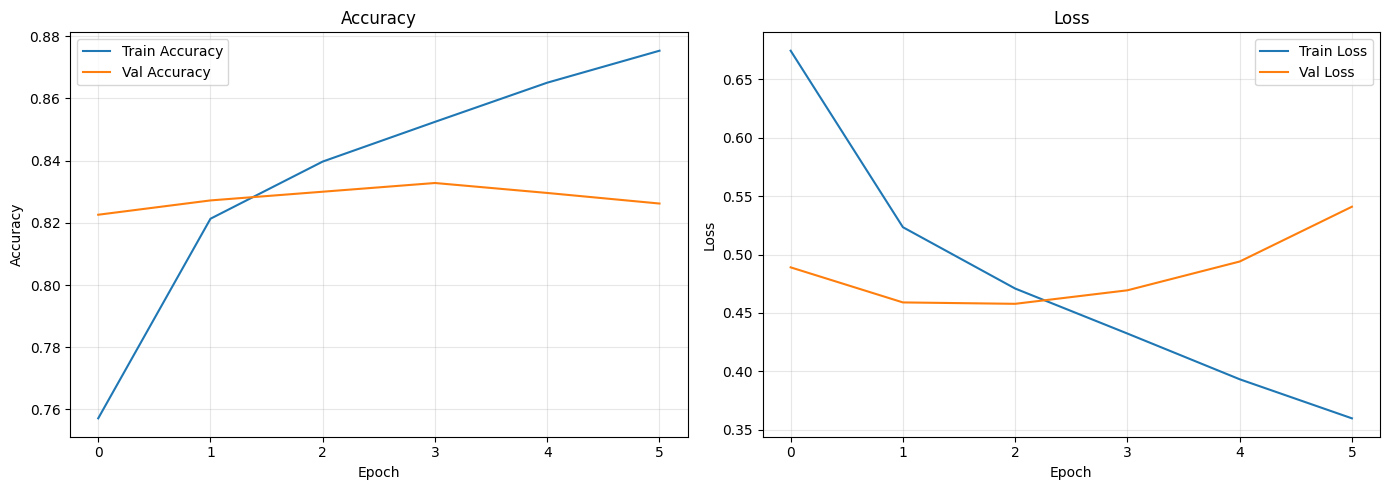

In [ ]:
# courbes d'netrainement

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

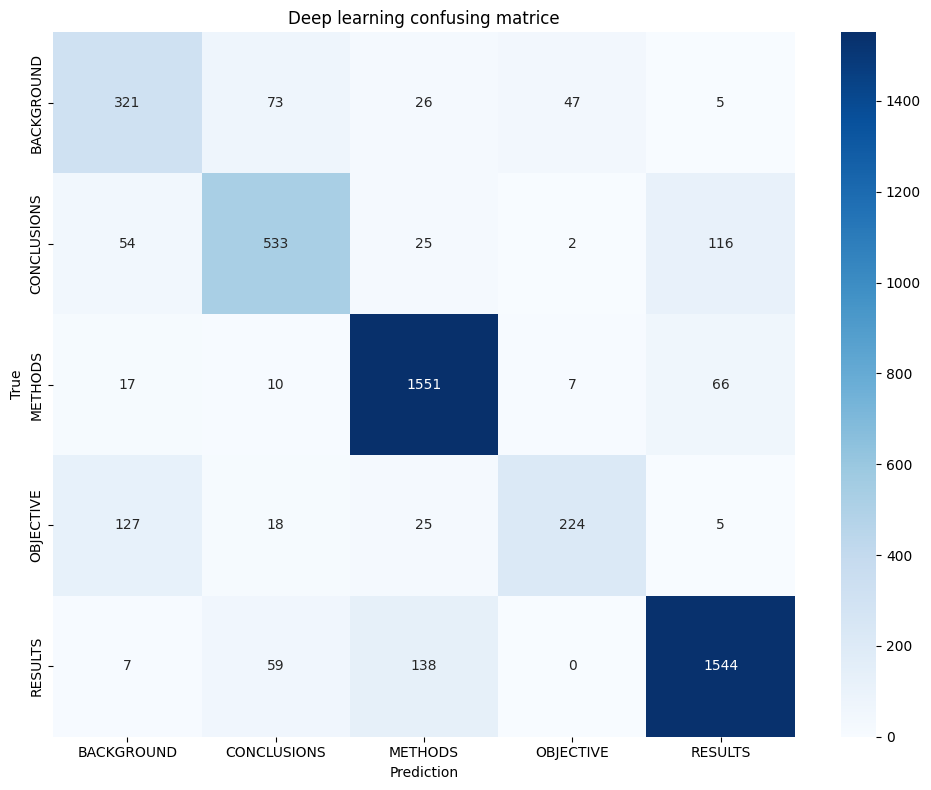

In [ ]:
# confusion matrice

plt.figure(figsize=(10, 8))
cm_dl = confusion_matrix(y_test_encoded, y_pred_classes)
sns.heatmap(cm_dl, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cmap='Blues')
plt.title('Deep learning confusing matrice')
plt.xlabel('Prediction')
plt.ylabel('True')
plt.tight_layout()
plt.show()

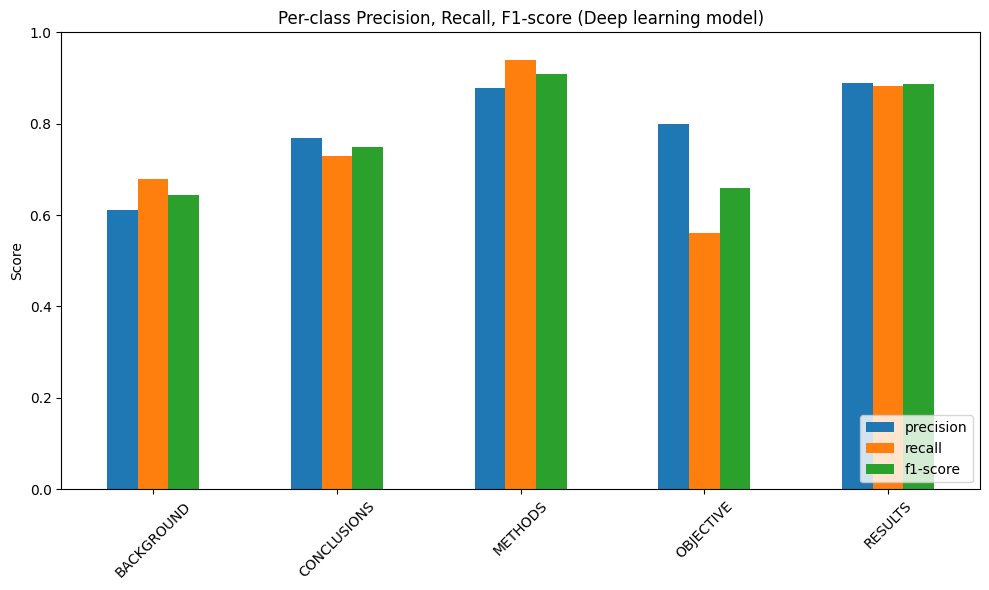

In [ ]:
# performance par classe

report_dl = classification_report(y_test_encoded, y_pred_classes,
                                 target_names=label_encoder.classes_,
                                 output_dict=True)
df_report_dl = pd.DataFrame(report_dl).transpose()
df_report_dl = df_report_dl.iloc[:-3]  # Exclure accuracy, macro avg, weighted avg

df_report_dl[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,6))
plt.title("Per-class Precision, Recall, F1-score (Deep learning model)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### COMPARISON

In [ ]:
acc_emb = 0.67
f1_emb = 0.58

In [ ]:
f1_baseline

0.537871331380489

                            Modèle  Accuracy  F1-Score
                Baseline (bigrams)  0.630082  0.537871
Pre-trained model words embeddings  0.670000  0.580000
              Deep learning (LSTM)  0.834600  0.769324


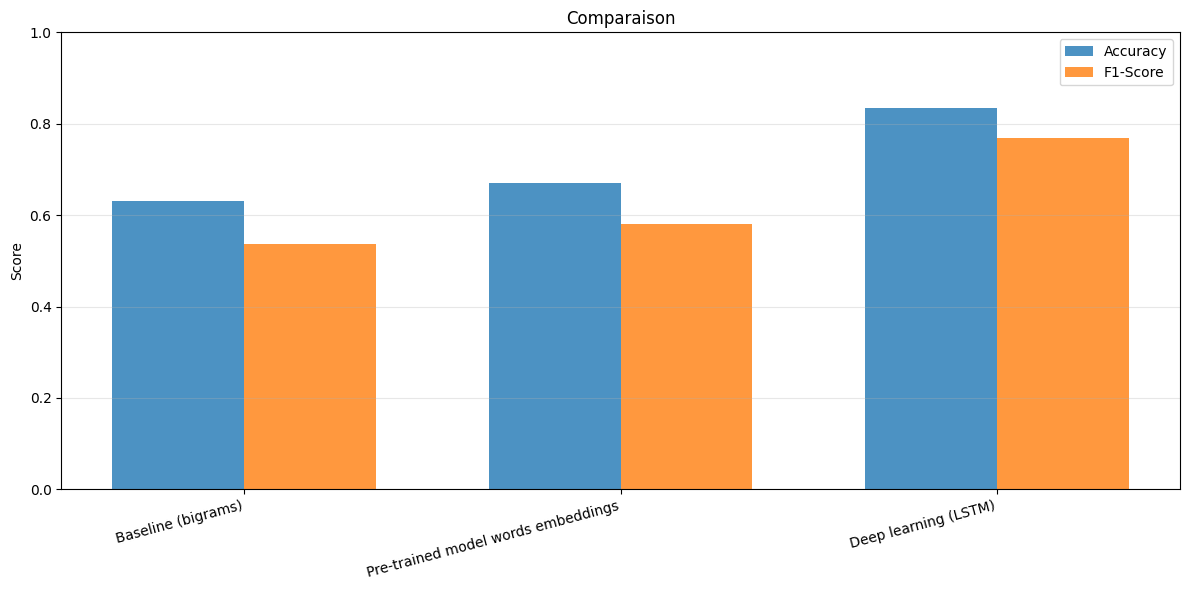

In [ ]:
results_comparison = pd.DataFrame({
    'Modèle': ['Baseline (bigrams)', 'Pre-trained model words embeddings', 'Deep learning (LSTM)'],
    'Accuracy': [acc_baseline, acc_emb, acc_dl],
    'F1-Score': [f1_baseline, f1_emb, f1_dl]
})

print(results_comparison.to_string(index=False))


plt.figure(figsize=(12, 6))
x = np.arange(len(results_comparison))
width = 0.35

plt.bar(x - width/2, results_comparison['Accuracy'], width,
        label='Accuracy', alpha=0.8)
plt.bar(x + width/2, results_comparison['F1-Score'], width,
        label='F1-Score', alpha=0.8)

plt.ylabel('Score')
plt.title('Comparaison')
plt.xticks(x, results_comparison['Modèle'], rotation=15, ha='right')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
